In [1]:
import pandas as pd
import numpy as np

np.random.seed(123)

municipios = [
    "Xicotepec",
    "Huauchinango",
    "Zacatlán",
    "Chignahuapan",
    "Venustiano Carranza",
    "Jalpan"
]

n = 4000

df = pd.DataFrame({
    "id_paciente": range(1, n+1),
    "municipio": np.random.choice(municipios, n),
    "edad": np.random.randint(20, 85, n),
    "sexo": np.random.choice(["Masculino", "Femenino"], n),
    "peso_kg": np.round(np.random.normal(74, 14, n), 2),
    "altura_m": np.round(np.random.normal(1.67, 0.10, n), 2),
    "presion_sistolica": np.random.randint(95, 190, n),
    "presion_diastolica": np.random.randint(65, 120, n),
    "colesterol_total": np.random.randint(130, 340, n),
    "glucosa": np.random.randint(75, 240, n),
    "fumador": np.random.choice([0,1], n),
    "alcohol": np.random.choice([0,1], n),
    "actividad_fisica": np.random.choice(["Baja","Media","Alta"], n),
    "antecedentes_familiares": np.random.choice([0,1], n),
    "oxigenacion": np.random.randint(88, 100, n),
    "frecuencia_cardiaca": np.random.randint(55, 145, n),
    "nivel_estres": np.random.randint(1,11, n)
})

# IMC
df["imc"] = round(df["peso_kg"] / (df["altura_m"]**2), 2)

# Cálculo de porcentaje de riesgo
riesgo = (
    (df["edad"] * 0.25) +
    (df["imc"] * 0.20) +
    (df["presion_sistolica"] * 0.15) +
    (df["colesterol_total"] * 0.10) +
    (df["glucosa"] * 0.10) +
    (df["fumador"] * 15) +
    (df["alcohol"] * 8) +
    (df["antecedentes_familiares"] * 12) +
    (df["nivel_estres"] * 2)
)

# Normalizar de 0 a 100
df["porcentaje_riesgo"] = ((riesgo - riesgo.min()) / (riesgo.max() - riesgo.min()) * 100).round(2)

# Guardar CSV
df.to_csv("dataset_riesgo_xicotepec.csv", index=False)

df.head()

,id_paciente,municipio,edad,sexo,peso_kg,altura_m,presion_sistolica,presion_diastolica,colesterol_total,glucosa,fumador,alcohol,actividad_fisica,antecedentes_familiares,oxigenacion,frecuencia_cardiaca,nivel_estres,imc,porcentaje_riesgo
0,1,Jalpan,26,Masculino,51.29,1.72,158,118,207,132,0,0,Media,0,98,142,9,17.34,28.55
1,2,Zacatlán,80,Masculino,51.36,1.80,119,70,271,174,1,0,Baja,1,91,94,2,15.85,59.49
2,3,Venustiano Carranza,82,Femenino,92.63,1.73,139,78,160,161,0,0,Media,1,99,141,7,30.95,48.61
3,4,Zacatlán,49,Femenino,82.44,1.58,112,66,271,193,1,1,Baja,0,96,135,7,33.02,62.02
4,5,Huauchinango,51,Femenino,47.73,1.72,116,77,316,228,1,1,Baja,1,89,97,8,16.13,81.73


In [2]:
pip install plotly folium seaborn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


# Análisis Exploratorio de Riesgo de Infarto en la Sierra Norte de Puebla
En este análisis exploraremos patrones geográficos, correlaciones médicas y factores de riesgo.

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap

df = pd.read_csv("dataset_riesgo_xicotepec.csv")

df.head()

,id_paciente,municipio,edad,sexo,peso_kg,altura_m,presion_sistolica,presion_diastolica,colesterol_total,glucosa,fumador,alcohol,actividad_fisica,antecedentes_familiares,oxigenacion,frecuencia_cardiaca,nivel_estres,imc,porcentaje_riesgo
0,1,Jalpan,26,Masculino,51.29,1.72,158,118,207,132,0,0,Media,0,98,142,9,17.34,28.55
1,2,Zacatlán,80,Masculino,51.36,1.80,119,70,271,174,1,0,Baja,1,91,94,2,15.85,59.49
2,3,Venustiano Carranza,82,Femenino,92.63,1.73,139,78,160,161,0,0,Media,1,99,141,7,30.95,48.61
3,4,Zacatlán,49,Femenino,82.44,1.58,112,66,271,193,1,1,Baja,0,96,135,7,33.02,62.02
4,5,Huauchinango,51,Femenino,47.73,1.72,116,77,316,228,1,1,Baja,1,89,97,8,16.13,81.73


## Mapa de calor de correlación
Nos permite identificar relaciones entre variables clínicas.

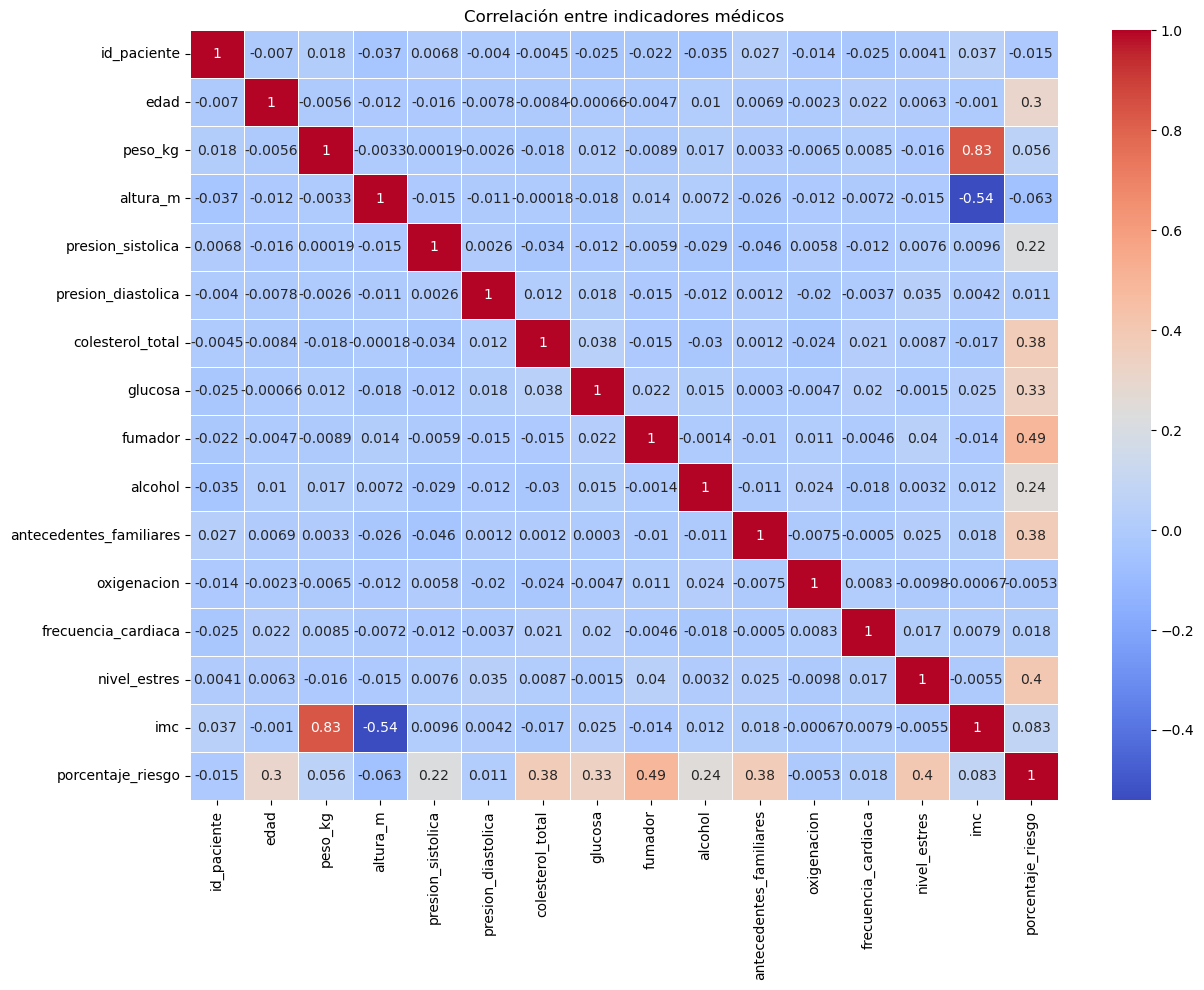

In [4]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlación entre indicadores médicos")
plt.show()

In [5]:
riesgo_municipio = df.groupby("municipio")["porcentaje_riesgo"].mean().reset_index()

fig = px.density_heatmap(
    riesgo_municipio,
    x="municipio",
    y="porcentaje_riesgo",
    title="Mapa de calor de riesgo promedio por municipio"
)

fig.show()

In [6]:
fig = px.scatter_matrix(
    df,
    dimensions=[
        "edad",
        "imc",
        "presion_sistolica",
        "colesterol_total",
        "glucosa",
        "porcentaje_riesgo"
    ],
    color="sexo",
    title="Relación multidimensional entre factores de riesgo"
)

fig.show()

In [7]:
coords = {
    "Xicotepec": [20.2767, -97.9611],
    "Huauchinango": [20.1738, -98.0557],
    "Zacatlán": [19.9350, -97.9619],
    "Chignahuapan": [19.8389, -98.0314],
    "Venustiano Carranza": [20.5092, -97.6681],
    "Jalpan": [20.4703, -97.9408]
}

In [8]:
mapa = folium.Map(
    location=[20.1, -97.95],
    zoom_start=9
)

heat_data = []

for _, row in df.iterrows():
    lat, lon = coords[row["municipio"]]
    heat_data.append([lat, lon, row["porcentaje_riesgo"]])

HeatMap(heat_data).add_to(mapa)

mapa

In [9]:
municipio_stats = df.groupby("municipio").agg({
    "porcentaje_riesgo":"mean",
    "edad":"mean"
}).reset_index()

municipio_stats["lat"] = municipio_stats["municipio"].map(lambda x: coords[x][0])
municipio_stats["lon"] = municipio_stats["municipio"].map(lambda x: coords[x][1])

fig = px.scatter_map(
    municipio_stats,
    lat="lat",
    lon="lon",
    size="porcentaje_riesgo",
    color="porcentaje_riesgo",
    hover_name="municipio",
    zoom=8,
    title="Mapa de burbujas del riesgo promedio"
)

fig.show()

In [10]:
fig = px.sunburst(
    df,
    path=["municipio", "sexo", "actividad_fisica"],
    values="porcentaje_riesgo",
    color="porcentaje_riesgo",
    title="Distribución jerárquica del riesgo"
)

fig.show()

In [11]:
fig = px.violin(
    df,
    x="sexo",
    y="porcentaje_riesgo",
    color="sexo",
    box=True,
    points="all",
    title="Distribución de riesgo por sexo"
)

fig.show()

In [12]:
promedios = {
    "Edad": df["edad"].mean(),
    "IMC": df["imc"].mean(),
    "Presión": df["presion_sistolica"].mean(),
    "Colesterol": df["colesterol_total"].mean(),
    "Glucosa": df["glucosa"].mean(),
    "Estrés": df["nivel_estres"].mean()
}

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=list(promedios.values()),
    theta=list(promedios.keys()),
    fill='toself'
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title="Perfil promedio de riesgo cardiovascular"
)

fig.show()

In [13]:
df["fecha_revision"] = pd.date_range(
    start="2026-01-01",
    periods=len(df),
    freq="H"
)

riesgo_tiempo = df.groupby(df["fecha_revision"].dt.date)["porcentaje_riesgo"].mean().reset_index()

fig = px.area(
    riesgo_tiempo,
    x="fecha_revision",
    y="porcentaje_riesgo",
    title="Evolución temporal del riesgo promedio"
)

fig.show()

C:\Users\derek\AppData\Local\Temp\ipykernel_21908\962233315.py:1: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

